In [8]:
import geopandas as gpd
import pandas as pd
from pyrosm import OSM
from shapely.geometry import Point

BASE = "/home/jovyan/work/children15mc"
PROC = f"{BASE}/data/processed"
RAW  = f"{BASE}/data/raw"
CASE = f"{BASE}/outputs/case"
LOCAL_PBF = f"{RAW}/greater-london-260812.osm.pbf"
CRS = 27700
CODE = "E01004275"
import os; os.makedirs(CASE, exist_ok=True)

df_a  = gpd.read_file(f"{PROC}/analysis_table.gpkg")
iso_d = gpd.read_file(f"{PROC}/isochrones_all.gpkg")
iso_b = gpd.read_file(f"{PROC}/isochrones_barrier.gpkg")
schools = gpd.read_file(f"{PROC}/schools_london.gpkg")
park_entries = gpd.read_file(f"{PROC}/park_entries.gpkg")

row = df_a[df_a.lsoa21cd == CODE].iloc[0]
d_geom = iso_d[iso_d.lsoa21cd == CODE].geometry.iloc[0]
b_geom = iso_b[iso_b.lsoa21cd == CODE].geometry.iloc[0]

#Layer 2
gpd.GeoDataFrame([{"lsoa21cd": CODE}], geometry=[row.geometry], crs=CRS) \
   .to_file(f"{CASE}/case_lsoa.gpkg", driver="GPKG")

#Layer 3 and 4
gpd.GeoDataFrame([{"type":"default"}], geometry=[d_geom], crs=CRS) \
   .to_file(f"{CASE}/case_iso_default.gpkg", driver="GPKG")
gpd.GeoDataFrame([{"type":"barrier"}], geometry=[b_geom], crs=CRS) \
   .to_file(f"{CASE}/case_iso_barrier.gpkg", driver="GPKG")

#Layer 5
bbox = gpd.GeoSeries([d_geom.buffer(400)], crs=CRS).to_crs(4326).iloc[0].bounds
osm = OSM(LOCAL_PBF, bounding_box=list(bbox))
rd = osm.get_network(network_type="driving").to_crs(CRS)
MAJOR = "motorway|trunk|primary|secondary|tertiary"
major = rd[rd["highway"].astype(str).str.contains(MAJOR, na=False)].copy()
major = major[major.intersects(d_geom.buffer(300))]
major = major[["name", "highway", "geometry"]]
major.to_file(f"{CASE}/case_major_roads.gpkg", driver="GPKG")
print(f"Major road: {len(major)}")
print(major["name"].value_counts().head(8).to_string())

#Layer 6
s_d = gpd.sjoin(schools, gpd.GeoDataFrame(geometry=[d_geom], crs=CRS),
                predicate="within").drop(columns="index_right")
s_d["reachable"] = s_d.geometry.within(b_geom).map({True:"Reachable",
                                                     False:"Not reachable"})
s_d[["EstablishmentName","reachable","geometry"]] \
   .to_file(f"{CASE}/case_schools.gpkg", driver="GPKG")
print(f"\nSchool: {len(s_d)}")
print(s_d[["EstablishmentName","reachable"]].to_string())

#Layer 7
gpd.GeoDataFrame([{"label":"Origin"}],
                 geometry=[Point(row.cent_x, row.cent_y)], crs=CRS) \
   .to_file(f"{CASE}/case_origin.gpkg", driver="GPKG")

#Layer 8
parks_data = OSM(LOCAL_PBF, bounding_box=list(bbox)) \
    .get_data_by_custom_criteria(custom_filter={"leisure":["park"]})
parks = parks_data[parks_data.geometry.type.isin(["Polygon","MultiPolygon"])].to_crs(CRS)
parks = parks[parks.intersects(d_geom)][["geometry"]].reset_index(drop=True)

pe_in_b = park_entries[park_entries.within(b_geom)]
parks["reachable"] = parks.geometry.apply(
    lambda g: "Reachable" if pe_in_b.intersects(g.buffer(30)).any() else "Not reachable")
parks.to_file(f"{CASE}/case_parks.gpkg", driver="GPKG")
print(f"\nPark: {len(parks)}")
print(parks["reachable"].value_counts().to_dict())

Major road: 25
name
East Ferry Road     12
Manchester Road      6
Westferry Road       5
Limeharbour          1
Spindrift Avenue     1

School: 3
                     EstablishmentName      reachable
319           Harbinger Primary School      Reachable
345        St Edmund's Catholic School  Not reachable
1152  Canary Wharf College, East Ferry  Not reachable

Park: 11
{'Not reachable': 11}


In [9]:
#Layer 9
cross_data = OSM(LOCAL_PBF, bounding_box=list(bbox)).get_data_by_custom_criteria(
    custom_filter={"highway": ["crossing"]}, extra_attributes=["crossing"])

cross = cross_data[cross_data.geometry.type == "Point"].to_crs(CRS)
cross = cross[cross.within(d_geom)].copy()

VALID = ["traffic_signals", "marked", "uncontrolled"]
cross["ctype"] = cross["crossing"].astype(str)
cross["status"] = cross["ctype"].apply(
    lambda x: "Signal-controlled" if x == "traffic_signals"
    else ("Marked" if x in ["marked", "uncontrolled"] else "Unmarked"))

cross[["ctype", "status", "geometry"]].to_file(
    f"{CASE}/case_crossings.gpkg", driver="GPKG")

print(f"Crossing points inside isochrones: {len(cross)}")
print(cross["status"].value_counts().to_dict())

Crossing points inside isochrones: 40
{'Unmarked': 27, 'Marked': 11, 'Signal-controlled': 2}


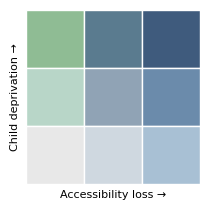

In [10]:
import matplotlib.pyplot as plt
import numpy as np

colors = [["#8FBC94","#5A7B8F","#3F5B7D"],
          ["#B8D6C8","#90A3B5","#6B8BAB"],
          ["#E8E8E8","#CFD8E0","#A8C0D4"]]

fig, ax = plt.subplots(figsize=(2.2,2.2))
for i in range(3):
    for j in range(3):
        ax.add_patch(plt.Rectangle((j,2-i),1,1,facecolor=colors[i][j],edgecolor='white',lw=1))
ax.set_xlim(0,3); ax.set_ylim(0,3)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel("Accessibility loss →", fontsize=8)
ax.set_ylabel("Child deprivation →", fontsize=8)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/bivar_legend.png", dpi=300, transparent=True)